Instalación sklearn
- pip install scikit-learn

In [26]:
# Importamos load_wine que nos devolverá un dataset para trabajar
from sklearn.datasets import load_wine
import pandas as pd

data = load_wine()
X, y = data.data, data.target

In [27]:
# Para exploración y para mayor claridad, transformamos los arrays de numpy en un df
df = pd.DataFrame(X, columns=data.feature_names)

# Agregar la columna target
df['target'] = y

In [28]:
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [29]:
df.target.value_counts()

target
1    71
0    59
2    48
Name: count, dtype: int64

In [30]:
df.target.unique()

array([0, 1, 2])

In [31]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

In [32]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
depth = 10
tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
tree.fit(X_train, y_train)
acc_train_shallow = accuracy_score(y_train, tree.predict(X_train))
acc_test_shallow = accuracy_score(y_test, tree.predict(X_test))

print("Árbol max_depth= %i -> Accuracy train: %.3f | test: %.3f" % (depth, acc_train_shallow, acc_test_shallow))

Árbol max_depth= 10 -> Accuracy train: 1.000 | test: 0.956


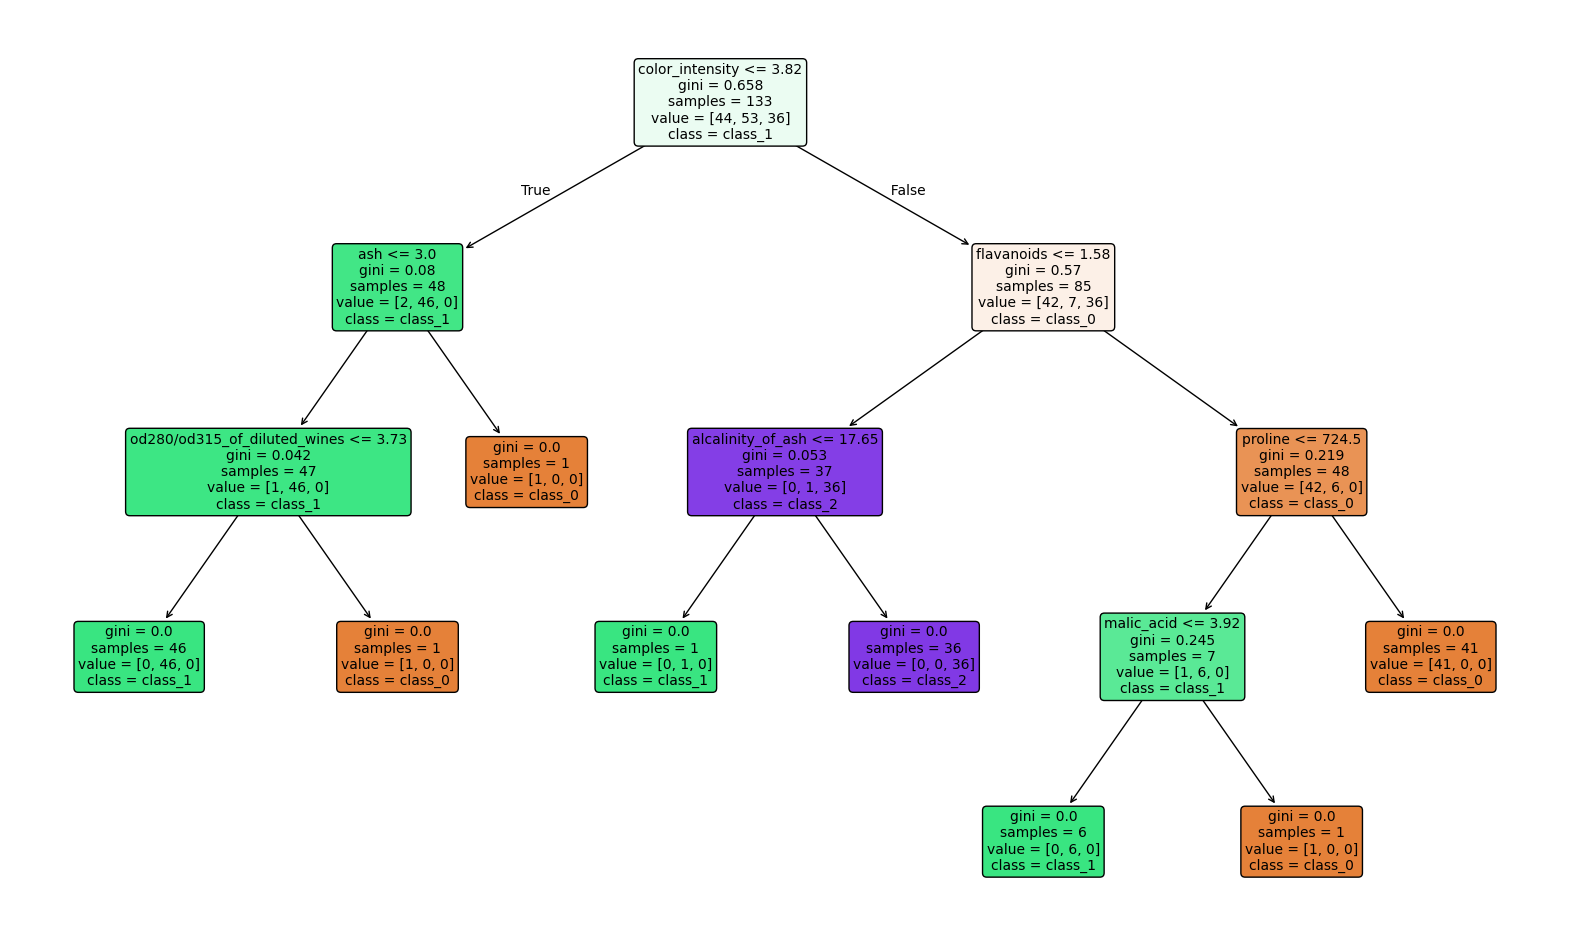

In [33]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20,12))
plot_tree(
    tree,
    filled=True,
    feature_names=load_wine().feature_names,
    class_names=load_wine().target_names,
    rounded=True,
    fontsize=10
)
plt.show()

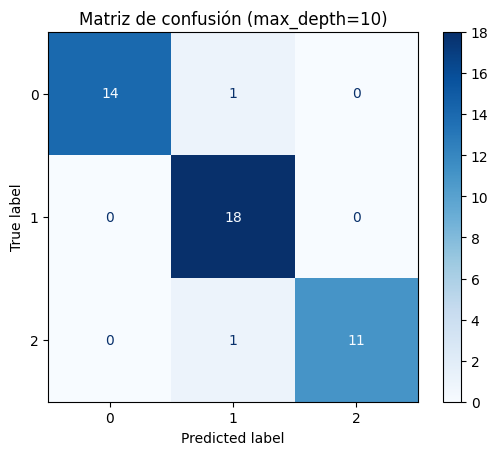

In [34]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

# Predicciones en test
y_pred_test = tree.predict(X_test)

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_test)

# Mostrar matriz de confusión
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title(f"Matriz de confusión (max_depth={depth})")
plt.show()

In [38]:
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       1.00      0.93      0.97        15
           1       0.90      1.00      0.95        18
           2       1.00      0.92      0.96        12

    accuracy                           0.96        45
   macro avg       0.97      0.95      0.96        45
weighted avg       0.96      0.96      0.96        45



In [36]:
(1*15+0.9*18+1*12)/(45)

0.9600000000000001

In [37]:
(1+0.9+1)/3

0.9666666666666667

Recall (fila) -> De todos los positivos reales, ¿cuántos detecté correctamente? 

Precision (columna) -> De todos los que predije como positivos, ¿cuántos lo eran realmente?